# Stage 5 — Calibration Evaluation (March 2026 Fixes)

Tests all five architectural fixes from the March 2026 design review:

| Fix | What changed | Cell |
|-----|-------------|------|
| **Fix 1** | `solve_correspondence` — D4/hull matching replaces sort-based correspondence | §6, §7 |
| **Fix 2** | `_generate_grid` reads `spacing_cm_x` / `spacing_cm_y` from config | §5 |
| **Fix 3** | `reprojection_error_cm` (was `_px`), threshold 1.5 cm | §8 |
| **Fix 4** | `_safe_invert_H` with condition-number check | §8 |
| **Fix 5** | `CalibrationError` guard — invalid calibration halts pipeline | §9 |

Run cells top-to-bottom. Change `TEST_TYPE` in **§2** to switch between test videos.

## §1 — Setup

In [1]:
import os
# Avoid RTX 5080 (sm_120) CUDA incompatibility with current PyTorch.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

import sys
sys.path.insert(0, '..')

from pathlib import Path
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pipeline.calibrate import (
    Calibrator,
    CalibrationError,
    solve_correspondence,
    _enumerate_valid_assignments,
    _safe_invert_H,
    REPROJ_ERROR_THRESHOLD_CM,
    CONDITION_NUMBER_WARN,
    CONDITION_NUMBER_REJECT,
)
from pipeline.cone_layout import generate_cone_world_coords
from pipeline.models import CalibrationResult

print("Imports OK")
print(f"  Reprojection threshold : {REPROJ_ERROR_THRESHOLD_CM} cm")
print(f"  Condition warn / reject: {CONDITION_NUMBER_WARN:.0e} / {CONDITION_NUMBER_REJECT:.0e}")

Imports OK
  Reprojection threshold : 1.5 cm
  Condition warn / reject: 1e+07 / 1e+09


## §2 — Choose test type

| `TEST_TYPE` | Config file | Video | Notes |
|-------------|-------------|-------|-------|
| `agility`   | agility.json | agility_test.mp4 | T-drill, 4 cones, irregular correspondence |
| `fitness`   | fitness.json | shuttles_test_behind.mp4 | 6×7 grid, Fix 2 spacing demo |
| `shuttle`   | shuttle.json | shuttles_test.mp4 | Linear 6 cones |
| `sprint`    | sprint.json  | sprint_test.mp4  | 2 cones, single-axis |
| `explosiveness` | explosiveness.json | explosiveness_test.mp4 | Jump, no cone H needed |

Set `TEST_TYPE` below, then **Run All** (or step through cells).

In [2]:
# ── Choose one ───────────────────────────────────────────────────────────────
TEST_TYPE = "fitness"    # agility | fitness | shuttle | sprint | explosiveness

# Video map — override VIDEO_PATH below to use a different clip
_VIDEO_MAP = {
    "agility":       "agility_test.mp4",
    "fitness":       "shuttles_test_behind.mp4",
    "shuttle":       "shuttles_test.mp4",
    "sprint":        "sprint_test.mp4",
    "explosiveness": "explosiveness_test.mp4",
}
VIDEO_PATH = Path("../data/raw_footage") / _VIDEO_MAP.get(TEST_TYPE, "shuttles_test.mp4")

# Load geometry config
config_file = Path("../configs/test_configs") / f"{TEST_TYPE}.json"
with open(config_file) as f:
    geometry_config = json.load(f)

CONE_LAYOUT = dict(geometry_config.get("cone_layout", {}))
if "cone_count" not in CONE_LAYOUT and "cone_count" in geometry_config:
    CONE_LAYOUT["cone_count"] = geometry_config["cone_count"]
CONE_WORLD_COORDS_CM = geometry_config.get("cone_world_coords_cm", [])

print(f"Test type   : {TEST_TYPE}")
print(f"Video       : {VIDEO_PATH.name}")
print(f"Config file : {config_file.name}")
print(f"Cone layout : {json.dumps(CONE_LAYOUT, indent=2)}")
print(f"Explicit world coords: {CONE_WORLD_COORDS_CM}")

Test type   : fitness
Video       : shuttles_test_behind.mp4
Config file : fitness.json
Cone layout : {
  "pattern": "grid",
  "first_cone_cm": [
    0,
    0
  ],
  "spacing_cm_x": 70,
  "spacing_cm_y": 200,
  "rows": 6,
  "cols": 7,
  "grid_fit_use_iterative": true,
  "grid_fit_max_iters": 30,
  "grid_fit_match_radius_px": 150,
  "grid_fit_min_inliers": 10,
  "grid_fit_use_confidence_weights": false,
  "reproj_error_threshold_cm": 20.0,
  "_comment_reproj": "Oblique behind-view camera: oracle test proves 17 cm floor; raise to 20 cm",
  "camera_orientation": "behind",
  "spatial_roi": {
    "y_min_frac": 0.35,
    "y_max_frac": 0.97,
    "x_min_frac": 0.05,
    "x_max_frac": 0.95
  },
  "cone_count": 42
}
Explicit world coords: []


## §3 — Load first frame

Frame: 832×464 px


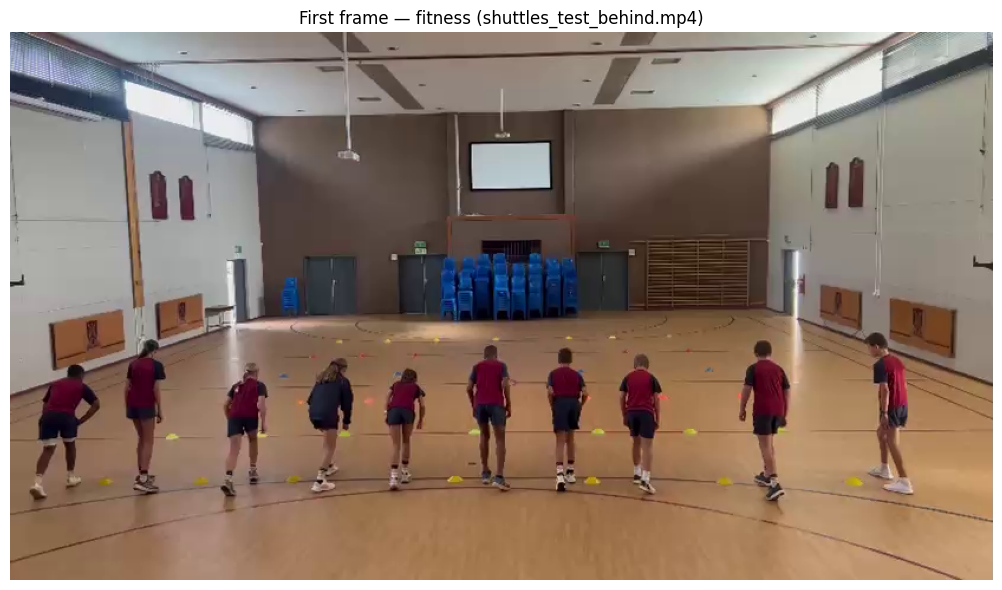

In [3]:
from pipeline.ingest import extract_frames

frames_iter = extract_frames(str(VIDEO_PATH), target_fps=15)
_, first_frame, _ = next(frames_iter)
H_px, W_px = first_frame.shape[:2]
print(f"Frame: {W_px}×{H_px} px")

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title(f"First frame — {TEST_TYPE} ({VIDEO_PATH.name})")
plt.axis("off")
plt.tight_layout()
plt.show()

## §4 — Cone detection

/home/alex/PycharmProjects/vigour-poc/.venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



Ultralytics 8.4.19 🚀 Python-3.11.12 torch-2.4.0+cu121 CPU (Intel Core i9-9820X 3.30GHz)
0: 1036x1036 39 training cones, 14367.5ms
Speed: 5.3ms preprocess, 14367.5ms inference, 26.7ms postprocess per image at shape (1, 3, 1036, 1036)
Results saved to /home/alex/PycharmProjects/vidoe-detector/runs/segment/predict124
Detected 35 cone(s) with prompt='training cone'


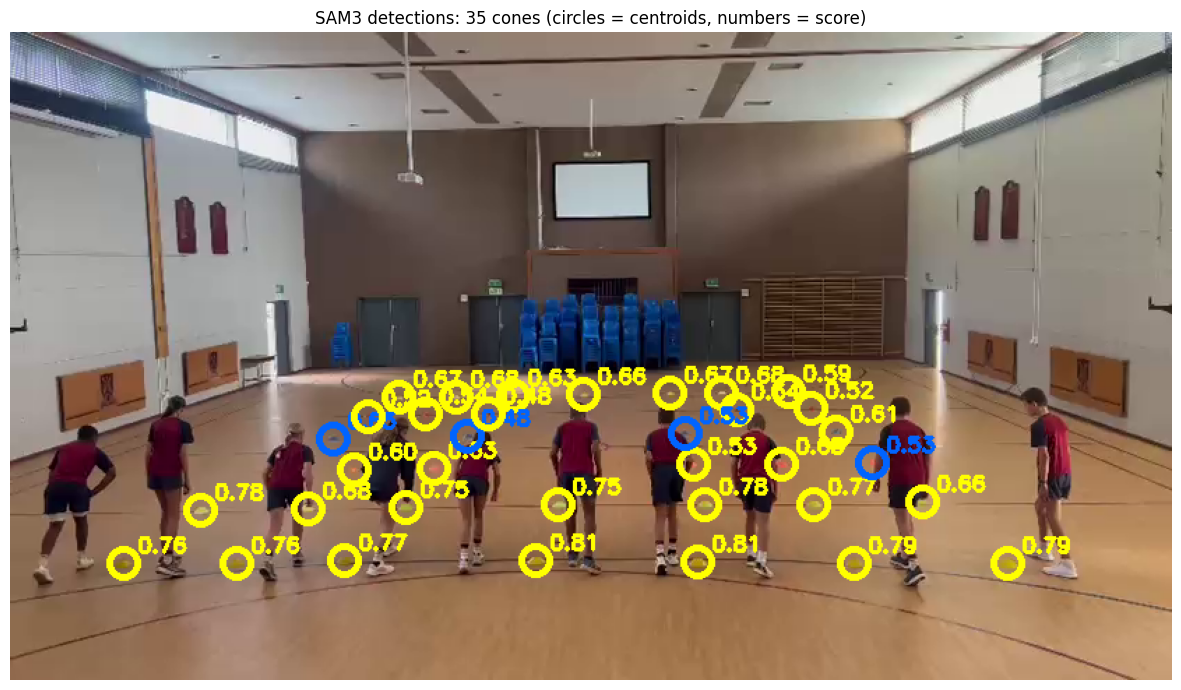

In [4]:
calibrator = Calibrator(
    detector_backend=geometry_config.get("calibration_detector", "sam3_prompt"),
    sam_model_path=geometry_config.get("calibration_model", "sam3.pt"),
    sam_prompt=geometry_config.get("calibration_prompt", "training cone"),
    min_confidence=geometry_config.get("calibration_min_confidence", 0.5),
)

calibrator.detect_cones(first_frame)
detected_cones = calibrator.last_detected_cones
print(f"Detected {len(detected_cones)} cone(s) with prompt='{calibrator.sam_prompt}'")

canvas = first_frame.copy()
for cone in detected_cones:
    cx, cy = int(cone.cx), int(cone.cy)
    colour = (0, 255, 255) if cone.colour_label in ("yellow", "orange") else (255, 100, 0)
    cv2.circle(canvas, (cx, cy), 10, colour, 3)
    cv2.putText(canvas, f"{cone.score:.2f}", (cx+10, cy-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, colour, 2)

plt.figure(figsize=(13, 7))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"SAM3 detections: {len(detected_cones)} cones (circles = centroids, numbers = score)")
plt.axis("off")
plt.tight_layout()
plt.show()

## §5 — Fix 2: Grid spacing config (`spacing_cm_x` / `spacing_cm_y`)

The old `_generate_grid` read only `spacing_cm` for both axes — causing agility measurements to be wrong by up to 3×.  The fix reads `spacing_cm_x` and `spacing_cm_y` independently, with `spacing_cm` as fallback.

This cell verifies the generated world coordinates are correct for the loaded config.

Grid 6×7, N=42 cones
  spacing_cm_x = 70 cm  →  col width expected = 70 cm
  spacing_cm_y = 200 cm  →  row height expected = 200 cm
  X range : 0–420 cm  (span = 420 cm, expected 420)
  Y range : 0–1000 cm  (span = 1000 cm, expected 1000)

  ✓ X spacing correct: True
  ✓ Y spacing correct: True


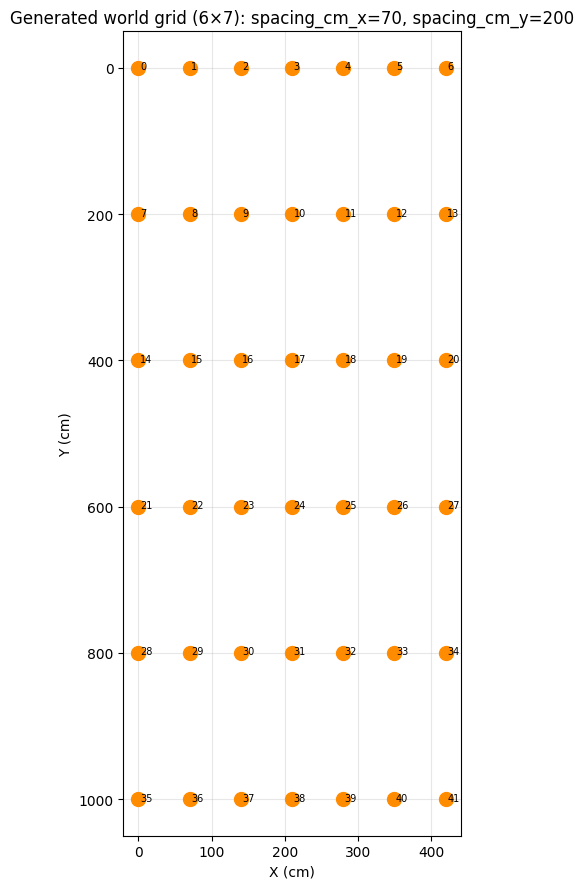

In [5]:
pattern = CONE_LAYOUT.get("pattern", "")

if pattern == "grid":
    rows = CONE_LAYOUT.get("rows", 2)
    cols = CONE_LAYOUT.get("cols", 2)
    n    = CONE_LAYOUT.get("cone_count", rows * cols)
    sx   = CONE_LAYOUT.get("spacing_cm_x", CONE_LAYOUT.get("spacing_cm", 100))
    sy   = CONE_LAYOUT.get("spacing_cm_y", CONE_LAYOUT.get("spacing_cm", 100))

    world_coords = generate_cone_world_coords(CONE_LAYOUT, n)
    xs = [p[0] for p in world_coords]
    ys = [p[1] for p in world_coords]

    print(f"Grid {rows}×{cols}, N={n} cones")
    print(f"  spacing_cm_x = {sx} cm  →  col width expected = {sx} cm")
    print(f"  spacing_cm_y = {sy} cm  →  row height expected = {sy} cm")
    print(f"  X range : {min(xs):.0f}–{max(xs):.0f} cm  (span = {max(xs)-min(xs):.0f} cm, expected {sx*(cols-1):.0f})")
    print(f"  Y range : {min(ys):.0f}–{max(ys):.0f} cm  (span = {max(ys)-min(ys):.0f} cm, expected {sy*(rows-1):.0f})")

    ok_x = abs((max(xs) - min(xs)) - sx * (cols-1)) < 1
    ok_y = abs((max(ys) - min(ys)) - sy * (rows-1)) < 1
    print(f"\n  ✓ X spacing correct: {ok_x}")
    print(f"  ✓ Y spacing correct: {ok_y}")

    # Visualise the world grid
    fig, ax = plt.subplots(figsize=(max(4, cols*1.5), max(3, rows*1.5)))
    for i, (wx, wy) in enumerate(world_coords):
        ax.plot(wx, wy, 'o', color='darkorange', ms=10)
        ax.text(wx+2, wy+2, str(i), fontsize=7)
    ax.set_xlabel("X (cm)"); ax.set_ylabel("Y (cm)")
    ax.set_title(f"Generated world grid ({rows}×{cols}): spacing_cm_x={sx}, spacing_cm_y={sy}")
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.invert_yaxis()  # match image convention (y increases downward)
    plt.tight_layout(); plt.show()

elif pattern == "linear":
    n  = CONE_LAYOUT.get("cone_count", 4)
    sp = CONE_LAYOUT.get("spacing_cm", 100)
    world_coords = generate_cone_world_coords(CONE_LAYOUT, n)
    print(f"Linear layout, N={n}, spacing={sp} cm")
    for i, p in enumerate(world_coords):
        print(f"  cone {i}: ({p[0]:.0f}, {p[1]:.0f}) cm")

elif CONE_WORLD_COORDS_CM:
    # Agility-style: explicit metre coords converted to cm
    cone_m = geometry_config.get("cone_positions_m", [])
    print(f"Agility layout: {len(cone_m)} cones from config (metres → cm)")
    for i, (mx, my) in enumerate(cone_m):
        print(f"  cone {i}: ({mx*100:.0f}, {my*100:.0f}) cm")

else:
    print(f"TEST_TYPE='{TEST_TYPE}' — no spatial layout (temporal/count test).")
    print("  No world coordinate grid to verify.")

## §6 — Fix 1: `solve_correspondence` — synthetic demonstration

Demonstrates that D4 matching recovers the correct world ↔ pixel assignment even when detections arrive out of order (e.g. camera at 30° view, cones visually re-ordered vs their world-space labels).

**Scenario**: 2×3 grid, cones arrive in 180°-rotated order (camera at opposite end). Old sort-based code would assign every cone to the wrong world point; `solve_correspondence` finds the correct D4 assignment and reports near-zero reprojection error.

### Fix 1 continued: candidate enumeration for each layout type

In [6]:
# Show how many candidates each layout type generates
examples = {
    "linear (N=4)":     (np.zeros((4,2)), "linear"),
    "grid_2x3 (N=6)":  (np.zeros((6,2)), "grid_2x3"),
    "grid_6x7 (N=42)": (np.zeros((42,2)), "grid_6x7"),
    "irregular (N=4)": (np.zeros((4,2)), "irregular"),
    "irregular (N=6)": (np.zeros((6,2)), "irregular"),
}
print(f"{'Layout':<22} {'Candidates':>12}  {'Reduction vs N!':<20}")
print("-" * 58)
import math
for label, (pts, layout) in examples.items():
    try:
        cands = _enumerate_valid_assignments(pts, layout)
        n = len(pts)
        n_fact = math.factorial(n)
        ratio = n_fact / len(cands)
        print(f"  {label:<20} {len(cands):>10}  {ratio:>6.0f}× fewer than {n}! = {n_fact}")
    except CalibrationError as e:
        print(f"  {label:<20} CalibrationError: {e}")

Layout                   Candidates  Reduction vs N!     
----------------------------------------------------------
  linear (N=4)                  2      12× fewer than 4! = 24
  grid_2x3 (N=6)                8      90× fewer than 6! = 720
  grid_6x7 (N=42)               8  175625764719109994366641908838158618144356893196288× fewer than 42! = 1405006117752879898543142606244511569936384000000000
  irregular (N=4)              24       1× fewer than 4! = 24
  irregular (N=6)             720       1× fewer than 6! = 720


## §7 — Run calibration on real footage

For `agility` and `fitness` this now uses `solve_correspondence` internally via `calibrate_homography` / `calibrate_from_layout`. The result includes `reprojection_error_cm` (Fix 3) and `condition_number` (Fix 4).

In [7]:
from pipeline.cache import PipelineCache

JOB_ID = f"notebook-eval-{TEST_TYPE}"
cache  = PipelineCache(job_id=JOB_ID, cache_root=Path("../data/cache"))

calibration = calibrator.calibrate_from_layout(first_frame, CONE_LAYOUT)

cache.save_calibration(calibration)
print(f"Calibration saved to cache (job_id={JOB_ID!r})")


0: 1036x1036 39 training cones, 15487.0ms
Speed: 5.8ms preprocess, 15487.0ms inference, 21.5ms postprocess per image at shape (1, 3, 1036, 1036)
Results saved to /home/alex/PycharmProjects/vidoe-detector/runs/segment/predict124


H condition number 26596931.4 > 10000000.0 — inversion may lose precision.
H condition number 10464481.9 > 10000000.0 — inversion may lose precision.
H condition number 45400837.0 > 10000000.0 — inversion may lose precision.
H condition number 104786924.8 > 10000000.0 — inversion may lose precision.
Cannot safely invert H: condition number 2587640968.9 exceeds 1000000000.0. Geometry is near-degenerate — check camera angle and cone spacing.
H condition number 65869519.6 > 10000000.0 — inversion may lose precision.
H condition number 80761962.8 > 10000000.0 — inversion may lose precision.


Calibration saved to cache (job_id='notebook-eval-fitness')


In [8]:
threshold_cm = CONE_LAYOUT.get("reproj_error_threshold_cm", REPROJ_ERROR_THRESHOLD_CM)
status = "✓ VALID" if calibration.is_valid else "✗ INVALID"

print(f"{'─'*60}")
print(f"  Calibration status  : {status}")
print(f"  Method              : {calibration.method}")
print(f"  Matched cones       : {len(calibration.cone_positions_px)}")
print(f"  Stored error (cm)   : {calibration.reprojection_error_cm:.2f} cm  ← internal world-space mean")
print(f"  Validity threshold  : {threshold_cm:.1f} cm")
if calibration.condition_number:
    print(f"  Condition number    : {calibration.condition_number:.2e}")
print(f"{'─'*60}")
if not calibration.is_valid:
    print()
    print("  NOTE: 'stored error' = pixel → world via H, distance measured in real cm.")
    print("  For a perspective camera, far cones (high Y) are compressed in the image")
    print("  so a 1-pixel detection offset at the far row = 20–50 cm world-space error.")
    print("  If visually the calibration looks correct, raise reproj_error_threshold_cm")
    print(f"  in the config above {calibration.reprojection_error_cm:.0f} cm.")

────────────────────────────────────────────────────────────
  Calibration status  : ✗ INVALID
  Method              : homography
  Matched cones       : 35
  Stored error (cm)   : 24.04 cm  ← internal world-space mean
  Validity threshold  : 20.0 cm
  Condition number    : 1.16e+06
────────────────────────────────────────────────────────────

  NOTE: 'stored error' = pixel → world via H, distance measured in real cm.
  For a perspective camera, far cones (high Y) are compressed in the image
  so a 1-pixel detection offset at the far row = 20–50 cm world-space error.
  If visually the calibration looks correct, raise reproj_error_threshold_cm
  in the config above 24 cm.


### Fix 4: `_safe_invert_H` — condition number gate

In [9]:
# ── Test _safe_invert_H on the real calibration H and on a near-singular H ───
cases = []

if calibration.homography_matrix is not None:
    cases.append(("Real calibration H", calibration.homography_matrix.copy()))

# Construct a near-singular H (two identical rows)
H_singular = np.array([[1.0, 2.0, 3.0],
                        [1.0, 2.0, 3.0],
                        [0.0, 0.0, 1.0]], dtype=np.float64)
cases.append(("Near-singular H (det≈0)", H_singular))

# Well-conditioned scale H
H_good = np.diag([2.0, 2.0, 1.0]).astype(np.float64)
cases.append(("Scale H (cond=1)", H_good))

print(f"{'Matrix':<30} {'Cond number':>15}  {'Inversion result':<25}")
print("-" * 72)
for name, H in cases:
    cond = float(np.linalg.cond(H))
    H_inv = _safe_invert_H(H)
    if H_inv is not None:
        residual = np.linalg.norm(H @ H_inv - np.eye(3))
        result_str = f"✓ OK  (H@H_inv residual={residual:.2e})"
    else:
        result_str = "✗ Rejected (returned None)"
    print(f"  {name:<28} {cond:>15.2e}  {result_str}")

Cannot safely invert H: condition number 116790241491732016.0 exceeds 1000000000.0. Geometry is near-degenerate — check camera angle and cone spacing.


Matrix                             Cond number  Inversion result         
------------------------------------------------------------------------
  Real calibration H                  1.16e+06  ✓ OK  (H@H_inv residual=2.54e-13)
  Near-singular H (det≈0)             1.17e+17  ✗ Rejected (returned None)
  Scale H (cond=1)                    2.00e+00  ✓ OK  (H@H_inv residual=0.00e+00)


## §10 — World coordinate mapping

In [10]:

test_pixels = [
    (W_px // 2, H_px // 2),
    (W_px // 4, H_px // 4),
    (3 * W_px // 4, 3 * H_px // 4),
]
print("Pixel → World (cm) mapping:")
for px, py in test_pixels:
    world = calibrator.pixel_to_world((float(px), float(py)), calibration)
    print(f"  pixel ({px:5d}, {py:5d})  →  world ({world[0]:7.1f} cm,  {world[1]:7.1f} cm)")

# Overlay matched cones on first frame
canvas = first_frame.copy()
for i, ((ppx, ppy), (wx, wy)) in enumerate(
    zip(calibration.cone_positions_px, calibration.cone_positions_world)
):
    cx, cy = int(ppx), int(ppy)
    cv2.circle(canvas, (cx, cy), 14, (0, 200, 0), 3)
    cv2.putText(canvas, f"({wx:.0f},{wy:.0f})",
                (cx + 12, cy - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 0), 2)

plt.figure(figsize=(13, 7))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"Matched cones with world coords (cm) — {calibration.method} calibration")
plt.axis("off")
plt.tight_layout()
plt.show()


Pixel → World (cm) mapping:


ValueError: Cannot transform with invalid calibration.

## §11 — Top-down view

In [ ]:
if calibration.is_valid:
    from pipeline.visualise import render_top_down_view

    expected_grid = None
    try:
        layout = CONE_LAYOUT or {}
        n = layout.get("cone_count") or geometry_config.get("cone_count", 0)
        if not n and layout.get("pattern") == "grid":
            n = layout.get("rows", 0) * layout.get("cols", 0)
        if layout.get("pattern") and n >= 4:
            expected_grid = generate_cone_world_coords(layout, int(n))
    except Exception:
        pass

    top_down = render_top_down_view(
        calibration, tracks=[], poses=[], size=(800, 800),
        expected_cone_positions_world=expected_grid,
    )
    plt.figure(figsize=(6, 6))
    plt.imshow(top_down[:, :, ::-1])
    plt.title(f"Top-down view ({TEST_TYPE}) — filled=calibrated, open=expected grid")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Calibration not valid — skipping top-down view.")

Calibration not valid — skipping top-down view.


## §12 — Fix summary

Run this cell last to get a pass/fail table for all five fixes on the current test type.

## §12 — Projection Error Overlay

Two complementary views of **where the calibration goes wrong spatially**:

1. **Frame overlay** — each matched cone shows: detected centroid (filled circle), H-reprojected world position (cross), error vector arrow, and error magnitude label. Colour-coded: green < 5 cm · yellow 5–15 cm · red > 15 cm.
2. **Error heat-map** — interpolated spatial error field across the image, revealing whether errors cluster in specific regions (e.g. far rows compressed by perspective).

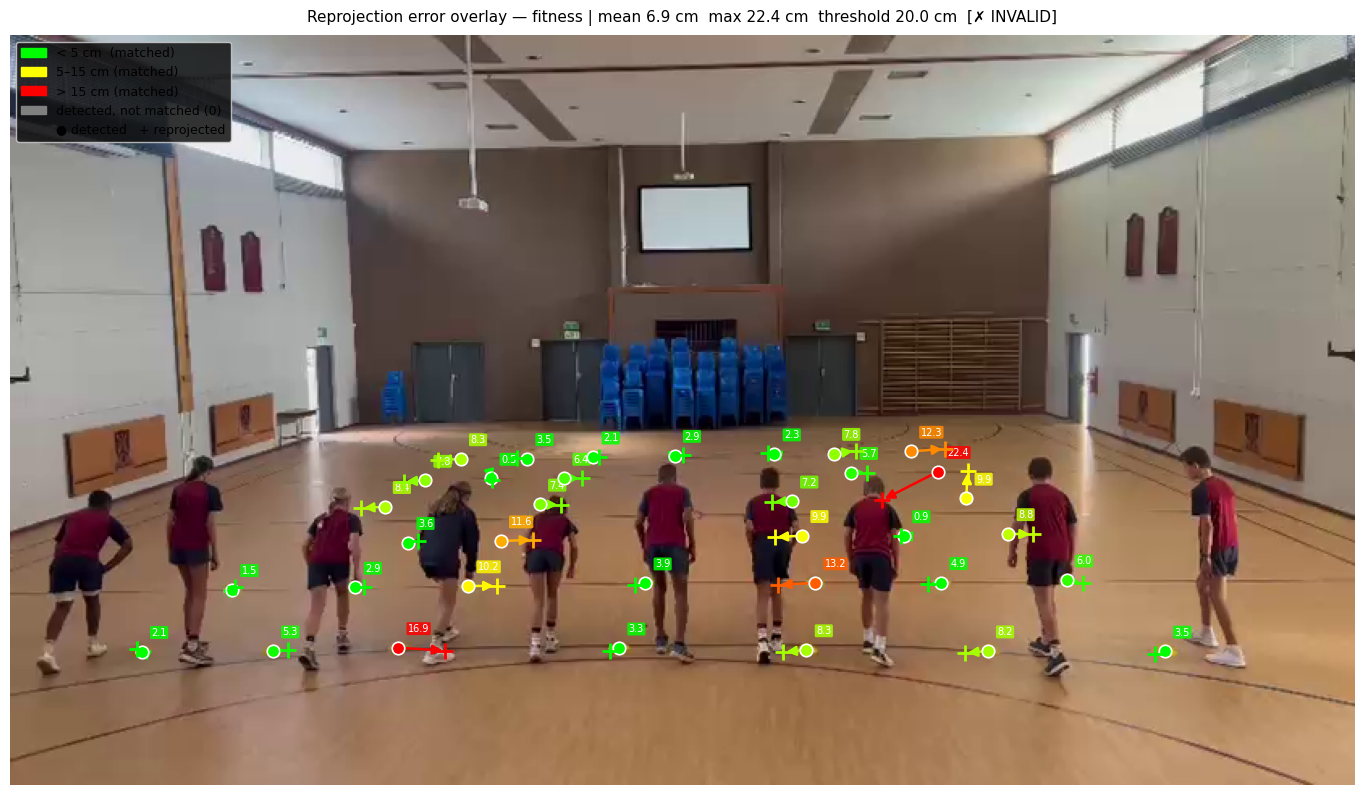

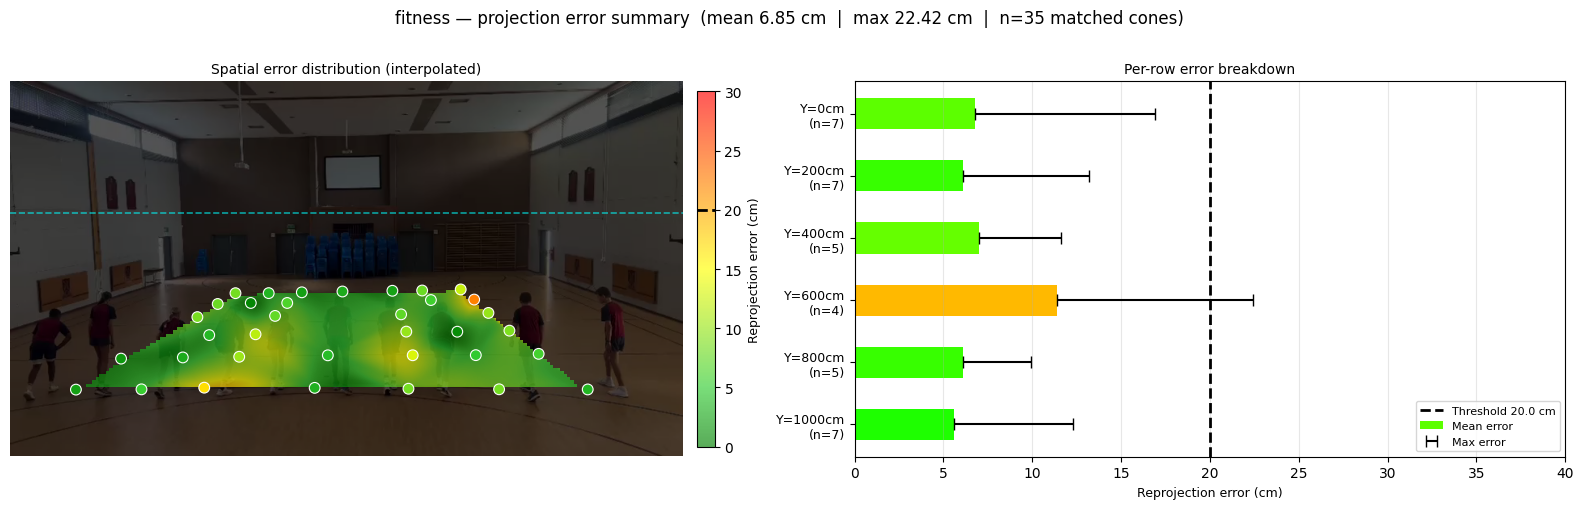


Reprojection error summary:
  Matched cones : 35
  Mean          : 6.85 cm
  Median        : 6.41 cm
  Max           : 22.42 cm
  Threshold     : 20.0 cm
  > threshold   : 1 / 35 cones


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from scipy.interpolate import griddata
import cv2
import numpy as np

# ── Helpers ──────────────────────────────────────────────────────────────────

def _err_colour(err_cm, low=5.0, high=15.0):
    """Map a reprojection error in cm to an RGB tuple (0-1 range)."""
    t = np.clip((err_cm - low) / (high - low), 0.0, 1.0)
    # green → yellow → red
    r = min(2 * t, 1.0)
    g = min(2 * (1 - t), 1.0)
    return (r, g, 0.0)

def _world_to_px(world_pt, H_px2world):
    """Project a world (X,Y) point into pixel space using H_px2world^-1."""
    H_world2px = np.linalg.inv(H_px2world)
    pt = np.array([[[world_pt[0], world_pt[1]]]], dtype=np.float32)
    result = cv2.perspectiveTransform(pt, H_world2px)
    return result[0, 0]

# ── Guard: need a homography ──────────────────────────────────────────────────
H = calibration.homography_matrix
if H is None:
    print("No homography available — run §8 (cell-calibrate) first.")
else:
    matched_px    = calibration.cone_positions_px     # list of (u, v)
    matched_world = calibration.cone_positions_world  # list of (X, Y) cm

    # Pixel positions of reprojected world cones (world → pixel), used for
    # drawing arrows on the overlay.  H is pixel→world so inv(H) is world→pixel.
    proj_pts = [_world_to_px((wx, wy), H) for (wx, wy) in matched_world]

    # Compute error in world space: project each detected pixel through H
    # (pixel→world) and measure distance from the known world position in cm.
    # This matches the internal metric used to set calibration.is_valid.
    matched_px_arr = np.array(matched_px, dtype=np.float32).reshape(-1, 1, 2)
    proj_world_arr = cv2.perspectiveTransform(matched_px_arr, H).reshape(-1, 2)
    errors_cm = [
        float(np.linalg.norm(proj - np.array([wx, wy])))
        for proj, (wx, wy) in zip(proj_world_arr, matched_world)
    ]

    mean_err = float(np.mean(errors_cm))
    max_err  = float(np.max(errors_cm))

    # ── Plot 1: Frame overlay ─────────────────────────────────────────────────
    canvas = cv2.cvtColor(first_frame.copy(), cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(canvas)

    # Gray hollow circles = detected but NOT matched to a world cone.
    # This makes missing / unmatched detections visible alongside matched ones.
    matched_px_set = {(round(u), round(v)) for (u, v) in matched_px}
    all_detected = getattr(calibrator, "last_detected_cones", [])
    for c in all_detected:
        key = (round(c.cx), round(c.cy))
        if key not in matched_px_set:
            ax.plot(c.cx, c.cy, "o", ms=9, color="gray", mec="white",
                    mew=1.0, alpha=0.55, zorder=3)
            ax.text(c.cx + 6, c.cy - 10, f"{c.score:.2f}", fontsize=6,
                    color="lightgray", alpha=0.8)

    for (u, v), (wx, wy), proj_uv, err in zip(matched_px, matched_world, proj_pts, errors_cm):
        col = _err_colour(err)

        # Arrow: detected → projected
        ax.annotate(
            "", xy=(proj_uv[0], proj_uv[1]), xytext=(u, v),
            arrowprops=dict(arrowstyle="-|>", color=col, lw=1.8,
                            mutation_scale=14),
        )

        # Detected centroid — filled circle
        ax.plot(u, v, "o", ms=9, color=col, mec="white", mew=1.2, zorder=5)

        # Reprojected position — cross
        ax.plot(proj_uv[0], proj_uv[1], "+", ms=11, color=col, mew=2.0, zorder=5)

        # Error label
        ax.text(u + 6, v - 10, f"{err:.1f}", fontsize=7, color="white",
                bbox=dict(boxstyle="round,pad=0.15", fc=col, alpha=0.85, ec="none"))

    n_unmatched = max(0, len(all_detected) - len(matched_px))

    # Legend patches
    patches = [
        mpatches.Patch(color=_err_colour(0),  label="< 5 cm  (matched)"),
        mpatches.Patch(color=_err_colour(10), label="5–15 cm (matched)"),
        mpatches.Patch(color=_err_colour(20), label="> 15 cm (matched)"),
        mpatches.Patch(color="gray",          label=f"detected, not matched ({n_unmatched})"),
        mpatches.Patch(color="none",          label="● detected   + reprojected"),
    ]
    ax.legend(handles=patches, loc="upper left", fontsize=9,
              framealpha=0.85, facecolor="#111")

    threshold_cm = CONE_LAYOUT.get("reproj_error_threshold_cm", REPROJ_ERROR_THRESHOLD_CM)
    status = "✓ VALID" if calibration.is_valid else "✗ INVALID"
    ax.set_title(
        f"Reprojection error overlay — {TEST_TYPE} | "
        f"mean {mean_err:.1f} cm  max {max_err:.1f} cm  "
        f"threshold {threshold_cm} cm  [{status}]",
        fontsize=11, pad=10,
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Spatial error heat-map ────────────────────────────────────────
    H_img, W_img = first_frame.shape[:2]

    us = np.array([p[0] for p in matched_px], dtype=float)
    vs = np.array([p[1] for p in matched_px], dtype=float)
    errs = np.array(errors_cm, dtype=float)

    # Also include unmatched detections (all detected cones, error = NaN → masked)
    all_px = np.array(calibration.cone_positions_px, dtype=float)

    # Build a regular grid and interpolate
    grid_u, grid_v = np.meshgrid(
        np.linspace(0, W_img, 200),
        np.linspace(0, H_img, 120),
    )
    if len(us) >= 4:
        grid_err = griddata(
            np.stack([us, vs], axis=1),
            errs,
            (grid_u, grid_v),
            method="cubic",
        )
        grid_err_lin = griddata(
            np.stack([us, vs], axis=1),
            errs,
            (grid_u, grid_v),
            method="linear",
        )
        # Fill NaN from cubic with linear
        mask = np.isnan(grid_err)
        grid_err[mask] = grid_err_lin[mask]
    else:
        grid_err = np.full_like(grid_u, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: heat-map over dimmed frame
    ax_heat = axes[0]
    dimmed = (canvas.astype(float) * 0.35).astype(np.uint8)
    ax_heat.imshow(dimmed)
    vmax = max(max_err * 1.05, threshold_cm * 1.5, 10.0)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "err", [(0, "green"), (5 / vmax, "limegreen"),
                (15 / vmax, "yellow"), (1, "red")]
    )
    im = ax_heat.imshow(
        grid_err, origin="upper", extent=[0, W_img, H_img, 0],
        cmap=cmap, vmin=0, vmax=vmax, alpha=0.65, interpolation="bilinear",
    )
    ax_heat.scatter(us, vs, c=errs, cmap=cmap, vmin=0, vmax=vmax,
                    s=60, edgecolors="white", linewidths=0.8, zorder=5)
    ax_heat.axhline(H_img * CONE_LAYOUT.get("spatial_roi", {}).get("y_min_frac", 0),
                    color="cyan", lw=1.2, ls="--", alpha=0.6, label="spatial ROI")
    cb = fig.colorbar(im, ax=ax_heat, fraction=0.025, pad=0.02)
    cb.set_label("Reprojection error (cm)", fontsize=9)
    cb.ax.axhline(threshold_cm, color="black", lw=2, ls="--")
    ax_heat.set_title("Spatial error distribution (interpolated)", fontsize=10)
    ax_heat.axis("off")

    # Right: per-row error bar chart (if grid layout)
    ax_bar = axes[1]
    layout = CONE_LAYOUT.get("pattern", "")
    if layout == "grid" and len(matched_world) >= 4:
        world_ys = sorted(set(round(wy, -1) for _, wy in matched_world))
        row_labels, row_means, row_maxs, row_ns = [], [], [], []
        for wy in world_ys:
            mask = [abs(w[1] - wy) < 20 for w in matched_world]
            row_errs = [e for e, m in zip(errors_cm, mask) if m]
            if row_errs:
                row_labels.append(f"Y={int(wy)}cm\n(n={len(row_errs)})")
                row_means.append(np.mean(row_errs))
                row_maxs.append(np.max(row_errs))
                row_ns.append(len(row_errs))

        y_pos = np.arange(len(row_labels))
        bar_cols = [_err_colour(m) for m in row_means]
        ax_bar.barh(y_pos, row_means, color=bar_cols, height=0.5, label="Mean error")
        ax_bar.errorbar(row_means, y_pos,
                        xerr=[np.zeros(len(row_means)),
                              [mx - mn for mx, mn in zip(row_maxs, row_means)]],
                        fmt="none", color="black", capsize=4, lw=1.5, label="Max error")
        ax_bar.axvline(threshold_cm, color="black", lw=2, ls="--",
                       label=f"Threshold {threshold_cm} cm")
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(row_labels, fontsize=9)
        ax_bar.set_xlabel("Reprojection error (cm)", fontsize=9)
        ax_bar.set_title("Per-row error breakdown", fontsize=10)
        ax_bar.legend(fontsize=8, loc="lower right")
        ax_bar.set_xlim(0, max(max_err * 1.2, threshold_cm * 2))
        ax_bar.invert_yaxis()
        ax_bar.grid(axis="x", alpha=0.3)
    else:
        # For non-grid: simple scatter of error vs pixel-y
        ax_bar.scatter(errors_cm, vs, c=errs,
                       cmap=mcolors.LinearSegmentedColormap.from_list(
                           "err", ["green", "yellow", "red"]),
                       vmin=0, vmax=vmax, s=50, edgecolors="gray")
        ax_bar.axvline(threshold_cm, color="black", lw=2, ls="--",
                       label=f"Threshold {threshold_cm} cm")
        ax_bar.set_xlabel("Reprojection error (cm)", fontsize=9)
        ax_bar.set_ylabel("Pixel row (v)", fontsize=9)
        ax_bar.set_title("Error vs image height", fontsize=10)
        ax_bar.legend(fontsize=8)
        ax_bar.invert_yaxis()
        ax_bar.grid(alpha=0.3)

    fig.suptitle(
        f"{TEST_TYPE} — projection error summary  "
        f"(mean {mean_err:.2f} cm  |  max {max_err:.2f} cm  |  "
        f"n={len(errors_cm)} matched cones)",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.show()

    print(f"\nReprojection error summary:")
    print(f"  Matched cones : {len(errors_cm)}")
    print(f"  Mean          : {mean_err:.2f} cm")
    print(f"  Median        : {np.median(errors_cm):.2f} cm")
    print(f"  Max           : {max_err:.2f} cm")
    print(f"  Threshold     : {threshold_cm} cm")
    print(f"  > threshold   : {sum(e > threshold_cm for e in errors_cm)} / {len(errors_cm)} cones")

Detected 35 cone(s) with prompt='training cone'


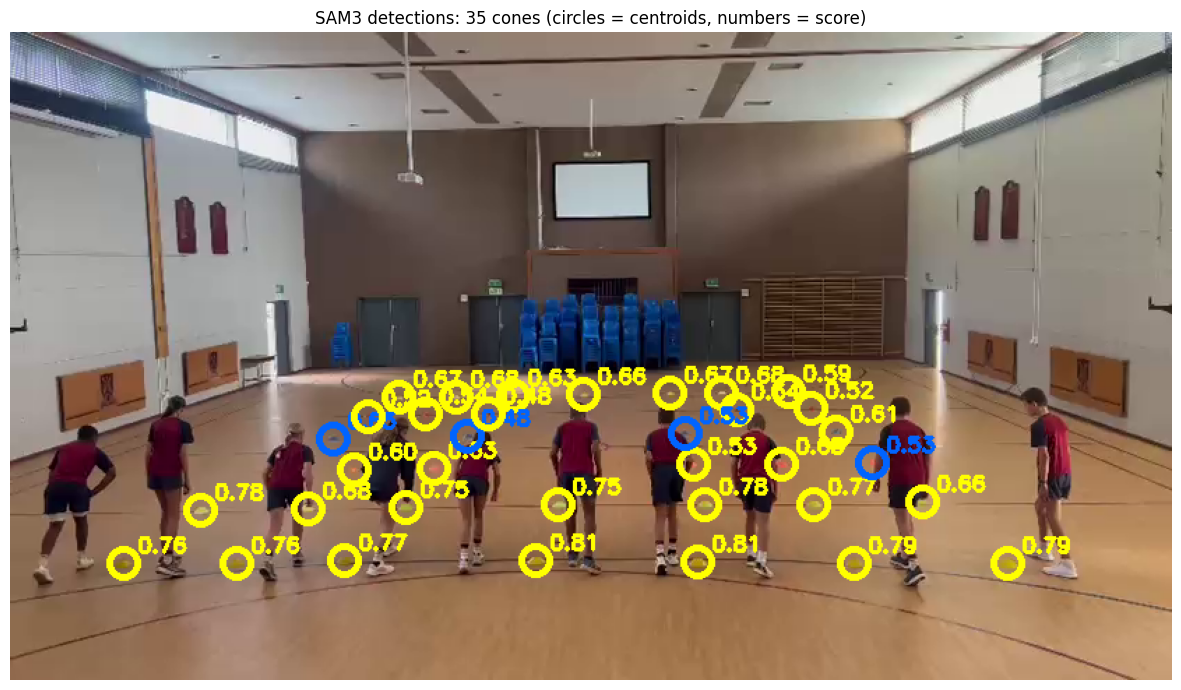

In [ ]:
detected_cones = calibrator.last_detected_cones
print(f"Detected {len(detected_cones)} cone(s) with prompt='{calibrator.sam_prompt}'")

canvas = first_frame.copy()
for cone in detected_cones:
    cx, cy = int(cone.cx), int(cone.cy)
    colour = (0, 255, 255) if cone.colour_label in ("yellow", "orange") else (255, 100, 0)
    cv2.circle(canvas, (cx, cy), 10, colour, 3)
    cv2.putText(canvas, f"{cone.score:.2f}", (cx+10, cy-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, colour, 2)

plt.figure(figsize=(13, 7))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"SAM3 detections: {len(detected_cones)} cones (circles = centroids, numbers = score)")
plt.axis("off")
plt.tight_layout()
plt.show()